
# Detailed Blockchain Lab Notebook with Visualizations
This notebook provides:
- Clear explanations for each concept
- A full blockchain implementation
- Proof-of-Work, difficulty, transactions, mining rewards
- Mining time visualization
---


**Note:
A real blockchain is a distributed system with multiple nodes, networks, consensus rules, and security mechanisms.
This notebook provides only a simplified, single‑node demonstration for learning purposes.**

##  Imports

In [1]:
import hashlib  # for SHA‑256 hashing
import json     # for JSON encoding
import time     # for timestamps and timing
import random   # for random test values
import matplotlib.pyplot as plt  # for plotting charts
from typing import List, Dict, Any  # for type hints

**Block Class**

A block contains transactions and must be mined by finding a valid hash starting with a number of leading zeros determined by the difficulty.

In [2]:

class Block:
    def __init__(self, index, timestamp, transactions, previous_hash, difficulty):
        self.index = index              # block number
        self.timestamp = timestamp      # time created
        self.transactions = transactions # list of txs
        self.previous_hash = previous_hash  # hash of previous block
        self.difficulty = difficulty    # mining difficulty
        self.nonce = 0                  # PoW counter
        self.hash = None                # final block hash

    def compute_hash(self):
        data = {
            "index": self.index,
            "timestamp": self.timestamp,
            "transactions": self.transactions,
            "previous_hash": self.previous_hash,
            "difficulty": self.difficulty,
            "nonce": self.nonce
        }

        return hashlib.sha256(json.dumps(data, sort_keys=True).encode()).hexdigest()  # compute hash

    def mine(self):
        target = '0' * self.difficulty  # target prefix
        start = time.time()             # start time
        attempts = 0                    # count tries
        while True:
            self.hash = self.compute_hash()  # calculate hash
            if self.hash.startswith(target):  # valid PoW?
                break
            self.nonce += 1                  # try next nonce
            attempts += 1
        return time.time() - start, attempts  # mining duration + attempts


##  Blockchain Class

The blockchain links blocks together and manages transactions, mining, verification, and exporting.

In [3]:

class Blockchain:
    def __init__(self, difficulty=3, reward=10):
        self.chain = []                # list of blocks
        self.difficulty = difficulty   # mining difficulty
        self.reward = reward           # block reward
        self.pending = []              # pending transactions
        self.create_genesis()          # create first block

    def create_genesis(self):
        b = Block(
            0,
            time.time(),
            [{"sender": "network", "recipient": "genesis", "amount": 0}],
            "0",
            self.difficulty
        )
        b.mine()                       # mine genesis block
        self.chain.append(b)           # add to chain

    def add_transaction(self, sender, recipient, amount):
        self.pending.append({
            "sender": sender,
            "recipient": recipient,
            "amount": amount
        })                             # store pending tx

    def mine_pending(self, miner):
        reward_tx = {"sender": "network", "recipient": miner, "amount": self.reward}
        txs = [reward_tx] + self.pending            # include reward + pending txs
        prev = self.chain[-1]                       # last block
        b = Block(len(self.chain), time.time(), txs, prev.hash, self.difficulty)
        t, attempts = b.mine()                      # mine new block
        self.chain.append(b)                        # add block to chain
        self.pending = []                           # clear mempool
        return t, attempts                          # return mining stats

    def export_json(self, filename):
        data = [b.__dict__ for b in self.chain]     # serialize blocks
        s = json.dumps(data, indent=2)              # format JSON
        open(filename, 'w').write(s)                # write file
        return s                                    # return JSON string


## 🚀 Example: Create Blockchain and Add Transactions

In [4]:

bc = Blockchain(difficulty=5, reward=25)   # create blockchain

# Add transactions
bc.add_transaction("Alice", "Bob", 10)      # Alice → Bob
bc.add_transaction("Bob", "Charlie", 5)     # Bob → Charlie
bc.add_transaction("Charlie", "Dave", 2)    # Charlie → Dave

time_taken, attempts = bc.mine_pending("Miner1")  # mine block + reward
print("Mining time:", time_taken, "seconds")       # show mining time
print("Attempts:", attempts)                       # show attempts made

Mining time: 8.509121656417847 seconds
Attempts: 543049


In [5]:
for b in bc.chain:
    print(f"Block #{b.index}")
    print(f" Timestamp   : {b.timestamp}")
    print(f" Hash        : {b.hash}")
    print(f" Prev Hash   : {b.previous_hash}")
    print(f" Difficulty  : {b.difficulty}")
    print(f" Nonce       : {b.nonce}")
    print(f" Transactions: {b.transactions}")
    print("-" * 50)

Block #0
 Timestamp   : 1775557364.234147
 Hash        : 000001e0dc6ce14b6c8988d7b3bbedd9852d35ddfdd42590a2ee25a1f8f789aa
 Prev Hash   : 0
 Difficulty  : 5
 Nonce       : 562405
 Transactions: [{'sender': 'network', 'recipient': 'genesis', 'amount': 0}]
--------------------------------------------------
Block #1
 Timestamp   : 1775557374.0306854
 Hash        : 000000d9a338ca283146e62cbb8de603556fe253601a241a957a9609f7961878
 Prev Hash   : 000001e0dc6ce14b6c8988d7b3bbedd9852d35ddfdd42590a2ee25a1f8f789aa
 Difficulty  : 5
 Nonce       : 543049
 Transactions: [{'sender': 'network', 'recipient': 'Miner1', 'amount': 25}, {'sender': 'Alice', 'recipient': 'Bob', 'amount': 10}, {'sender': 'Bob', 'recipient': 'Charlie', 'amount': 5}, {'sender': 'Charlie', 'recipient': 'Dave', 'amount': 2}]
--------------------------------------------------


## Mining Time Visualization

We test multiple difficulty levels and plot the mining times to show how difficulty impacts mining cost.

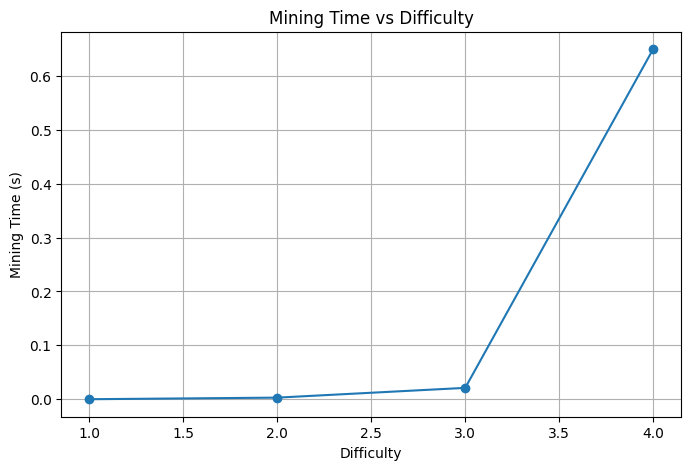

In [6]:

difficulties = [1, 2, 3, 4]        # test difficulty levels
times = []                         # store mining times

for d in difficulties:
    bc = Blockchain(difficulty=d, reward=1)  # new chain per difficulty
    bc.add_transaction("A", "B", 1)          # simple tx
    t, att = bc.mine_pending("MinerX")       # mine and time
    times.append(t)                           # record time

plt.figure(figsize=(8, 5))                   # set figure size
plt.plot(difficulties, times, marker='o')    # line plot with markers
plt.xlabel('Difficulty')                     # x-axis label
plt.ylabel('Mining Time (s)')                # y-axis label
plt.title('Mining Time vs Difficulty')       # chart title
plt.grid(True)                               # show grid
plt.show()                                   # render plot


#  Student Challenges
1. Note that your data is not encrypted inside the blocks, so anyone can read it. Encrypt the data before storing it in each block. Use encryption methods such as AES or 3DES.

2. Modify the mining function so it no longer uses leading‑zero matching; instead apply a different Proof‑of‑Work rule, such as a numeric hash threshold, pattern matching, or a time‑limited mining attempt.

Some options can be:

* Numeric threshold: Convert the hash to an integer and check if it's below a target value.
* Pattern rule: Make the hash end with certain characters (e.g., "00"), or require a substring inside the hash.
* Time‑limited PoW: Stop mining after a fixed time or attempt limit and mark the block as failed.
* Difficulty idea: Control difficulty by adjusting pattern length or the numeric target size.


# LAB-LOGBOOK requirement:
Show a graph comparing the mining time of the different Proof‑of‑Work methods used in Challenge 2.









In [7]:
import hashlib  # for SHA-256 hashing
import json     # for JSON encoding
import time     # for timestamps and timing
import random   # for random test values
import matplotlib.pyplot as plt  # for plotting charts
from typing import List, Dict, Any  # for type hints
from cryptography.fernet import Fernet # for AES encryption

In [8]:

class Block:
    def __init__(self, index, timestamp, transactions, previous_hash, difficulty, encryption_key):
        self.index = index              # block number
        self.timestamp = timestamp      # time created
        self.previous_hash = previous_hash  # hash of previous block
        self.difficulty = difficulty    # mining difficulty
        self.nonce = 0                  # PoW counter
        self.hash = None                # final block hash

        self.cipher = Fernet(encryption_key)
        self.transactions_encrypted = self._encrypt_transactions(transactions)

    def _encrypt_transactions(self, transactions):
        json_data = json.dumps(transactions, sort_keys=True)
        return self.cipher.encrypt(json_data.encode('utf-8')).decode('utf-8')

    def decrypt_transactions(self):
        decrypted_bytes = self.cipher.decrypt(self.transactions_encrypted.encode('utf-8'))
        return json.loads(decrypted_bytes.decode('utf-8'))

    def compute_hash(self):
        data = {
            "index": self.index,
            "timestamp": self.timestamp,
            "transactions_encrypted": self.transactions_encrypted,
            "previous_hash": self.previous_hash,
            "difficulty": self.difficulty,
            "nonce": self.nonce
        }
        return hashlib.sha256(json.dumps(data, sort_keys=True).encode()).hexdigest()

    def _mine_leading_zeros(self):
        target = '0' * self.difficulty
        attempts = 0
        while True:
            self.hash = self.compute_hash()
            if self.hash.startswith(target):
                break
            self.nonce += 1
            attempts += 1
        return attempts

    def _mine_numeric_threshold(self):
        # For numeric threshold, we make the target value depend on difficulty
        # Lower target means higher difficulty
        max_hash_int = int('f' * 64, 16) # Max possible SHA256 hash value
        # Example: difficulty=1 => target is max_hash_int // 10
        # difficulty=2 => target is max_hash_int // 100, etc.
        target_threshold = max_hash_int // (10 ** self.difficulty)

        attempts = 0
        while True:
            self.hash = self.compute_hash()
            hash_as_int = int(self.hash, 16)
            if hash_as_int < target_threshold:
                break
            self.nonce += 1
            attempts += 1
        return attempts

    def _mine_pattern_matching(self):
        # Modified: Require the hash to END with a certain number of '0's
        # Ensuring pattern length is not too long for demonstration
        pattern_length = max(1, min(self.difficulty, 2)) # At least 1, max 2 zeros for pattern
        target_suffix = '0' * pattern_length

        attempts = 0
        while True:
            self.hash = self.compute_hash()
            if self.hash.endswith(target_suffix):
                break
            self.nonce += 1
            attempts += 1
        return attempts

    def _mine_time_limited(self, time_limit=5):
        start_time = time.time()
        attempts = 0
        self.hash = None # Reset hash for this method

        # For a time-limited PoW, the primary constraint is time. We aim to find *any* hash
        # that satisfies a *minimal* condition within the time limit. If no condition is met,
        # the block is still considered 'mined' after the time, with the last computed hash.
        # This simulates a scenario where miners contribute work for a fixed duration.
        while time.time() - start_time < time_limit:
            self.hash = self.compute_hash()
            # An optional weak condition, for instance, a hash that doesn't start with '0'
            # This makes it likely to find *a* hash, but doesn't make it truly difficult
            if self.hash and not self.hash.startswith('0'):
                # This condition is just for demonstration, it's very easy to meet
                # The actual difficulty comes from the time constraint itself
                pass
            self.nonce += 1
            attempts += 1

        # Ensure a hash is set even if time expires before any condition is met
        if not self.hash:
            self.hash = self.compute_hash() # Compute one final hash if no attempts happened or hash was not set

        return attempts

    def mine(self, pow_method='leading_zeros', time_limit=None):
        start = time.time()
        attempts = 0
        if pow_method == 'leading_zeros':
            attempts = self._mine_leading_zeros()
        elif pow_method == 'numeric_threshold':
            attempts = self._mine_numeric_threshold()
        elif pow_method == 'pattern_matching':
            attempts = self._mine_pattern_matching()
        elif pow_method == 'time_limited':
            attempts = self._mine_time_limited(time_limit=time_limit if time_limit else 0.5) # Default to 0.5s for testing
        else:
            raise ValueError("Invalid Proof-of-Work method specified.")

        return time.time() - start, attempts


In [9]:

class Blockchain:
    def __init__(self, difficulty=3, reward=10, encryption_key=None, pow_method='leading_zeros'):
        self.chain = []                # list of blocks
        self.difficulty = difficulty   # mining difficulty
        self.reward = reward           # block reward
        self.pending = []              # pending transactions
        self.encryption_key = encryption_key if encryption_key else Fernet.generate_key()
        self.pow_method = pow_method # New: Proof-of-Work method
        self.create_genesis()          # create first block

    def create_genesis(self):
        b = Block(
            0,
            time.time(),
            [{"sender": "network", "recipient": "genesis", "amount": 0}],
            "0",
            self.difficulty,
            self.encryption_key
        )
        # Pass the PoW method to the block's mine function
        # Genesis block for time_limited PoW still needs to 'mine' for a moment
        genesis_time_limit = 0.1 # A very short time for genesis
        t, att = b.mine(pow_method=self.pow_method, time_limit=genesis_time_limit)
        self.chain.append(b)

    def add_transaction(self, sender, recipient, amount):
        self.pending.append({
            "sender": sender,
            "recipient": recipient,
            "amount": amount
        })

    def mine_pending(self, miner, time_limit=None):
        reward_tx = {"sender": "network", "recipient": miner, "amount": self.reward}
        txs = [reward_tx] + self.pending
        prev = self.chain[-1]
        b = Block(len(self.chain), time.time(), txs, prev.hash, self.difficulty, self.encryption_key)
        # Pass the PoW method and time_limit to the block's mine function
        t, attempts = b.mine(pow_method=self.pow_method, time_limit=time_limit)
        self.chain.append(b)
        self.pending = []
        return t, attempts

    def export_json(self, filename):
        data = []
        for b in self.chain:
            block_data = b.__dict__.copy()
            block_data['transactions'] = b.decrypt_transactions()
            data.append(block_data)

        s = json.dumps(data, indent=2)
        open(filename, 'w').write(s)
        return s


In [10]:
bc = Blockchain(difficulty=5, reward=25)   # create blockchain

# Add transactions
bc.add_transaction("Alice", "Bob", 10)      # Alice → Bob
bc.add_transaction("Bob", "Charlie", 5)     # Bob → Charlie
bc.add_transaction("Charlie", "Dave", 2)    # Charlie → Dave

time_taken, attempts = bc.mine_pending("Miner1")  # mine block + reward
print("Mining time:", time_taken, "seconds")       # show mining time
print("Attempts:", attempts)                       # show attempts made

Mining time: 4.308642148971558 seconds
Attempts: 399938


In [11]:
for b in bc.chain:
    print(f"Block #{b.index}")
    print(f" Timestamp   : {b.timestamp}")
    print(f" Hash        : {b.hash}")
    print(f" Prev Hash   : {b.previous_hash}")
    print(f" Difficulty  : {b.difficulty}")
    print(f" Nonce       : {b.nonce}")

    # Decrypt transactions for display
    print(f" Transactions: {b.decrypt_transactions()}")
    print(f" Encrypted Txs: {b.transactions_encrypted}") # Show encrypted form too
    print("-" * 50)

Block #0
 Timestamp   : 1775557385.3917646
 Hash        : 000009798d58a26aa9a81d79f7969da4cd425baffc7236d0addbfa01846fa323
 Prev Hash   : 0
 Difficulty  : 5
 Nonce       : 58448
 Transactions: [{'amount': 0, 'recipient': 'genesis', 'sender': 'network'}]
 Encrypted Txs: gAAAAABp1NsJ5ha7AYMZYToENjMbzXJJZfDDzpHR3gy_bbUmqRLwEHCFmYLAVxqro6orJmRBgQ67drA7j5lu6V3_3Wx20zcG9Fi6v1YehRnWVtOsMYtvMqDFJV2t9e7pYGVXY7tLYqaKfSotyjXNEPdpk9Q3Mhfqtg==
--------------------------------------------------
Block #1
 Timestamp   : 1775557385.9073582
 Hash        : 000000f5e38cb058e3d6cd73b7870e3581fc8118b0d406133b268aa3df36860a
 Prev Hash   : 000009798d58a26aa9a81d79f7969da4cd425baffc7236d0addbfa01846fa323
 Difficulty  : 5
 Nonce       : 399938
 Transactions: [{'amount': 25, 'recipient': 'Miner1', 'sender': 'network'}, {'amount': 10, 'recipient': 'Bob', 'sender': 'Alice'}, {'amount': 5, 'recipient': 'Charlie', 'sender': 'Bob'}, {'amount': 2, 'recipient': 'Dave', 'sender': 'Charlie'}]
 Encrypted Txs: gAAAAABp1NsJ

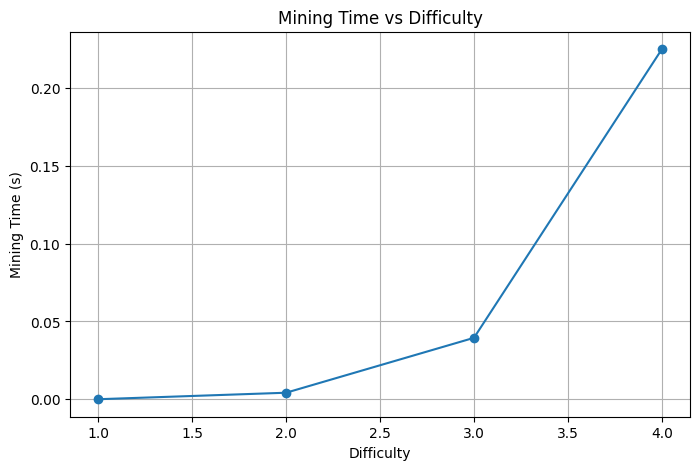

In [12]:

difficulties = [1, 2, 3, 4]        # test difficulty levels
times = []                         # store mining times

for d in difficulties:
    # Generate a new key for each blockchain instance to ensure isolation
    encryption_key = Fernet.generate_key()
    bc = Blockchain(difficulty=d, reward=1, encryption_key=encryption_key)  # new chain per difficulty
    bc.add_transaction("A", "B", 1)          # simple tx
    t, att = bc.mine_pending("MinerX")       # mine and time
    times.append(t)                           # record time

plt.figure(figsize=(8, 5))                   # set figure size
plt.plot(difficulties, times, marker='o')    # line plot with markers
plt.xlabel('Difficulty')                     # x-axis label
plt.ylabel('Mining Time (s)')                # y-axis label
plt.title('Mining Time vs Difficulty')       # chart title
plt.grid(True)                               # show grid
plt.show()                                   # render plot


--- Comparing Different Proof-of-Work Methods ---

Testing PoW Method: Leading Zeros
Block 1 mined in 0.0119 seconds (attempts: 1212)
Block 2 mined in 0.0035 seconds (attempts: 283)
Block 3 mined in 0.0905 seconds (attempts: 8699)

Testing PoW Method: Numeric Threshold
Block 1 mined in 0.0028 seconds (attempts: 239)
Block 2 mined in 0.0029 seconds (attempts: 248)
Block 3 mined in 0.0039 seconds (attempts: 400)

Testing PoW Method: Pattern Matching
Block 1 mined in 0.0021 seconds (attempts: 206)
Block 2 mined in 0.0004 seconds (attempts: 42)
Block 3 mined in 0.0011 seconds (attempts: 96)

Testing PoW Method: Time Limited
Block 1 mined in 0.5000 seconds (attempts: 25659)
Block 2 mined in 0.5000 seconds (attempts: 15768)
Block 3 mined in 0.5005 seconds (attempts: 9307)


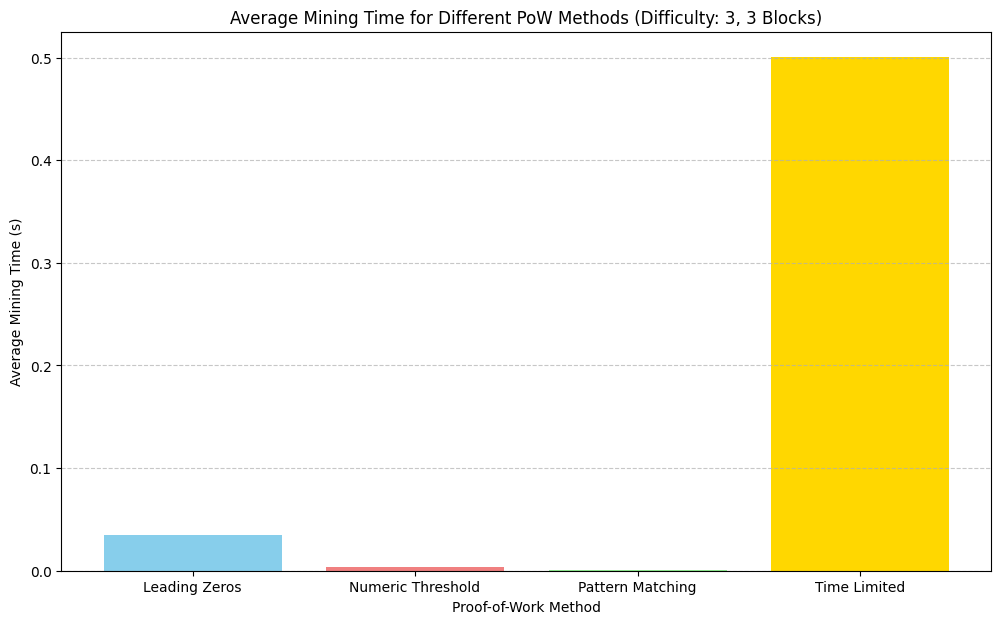

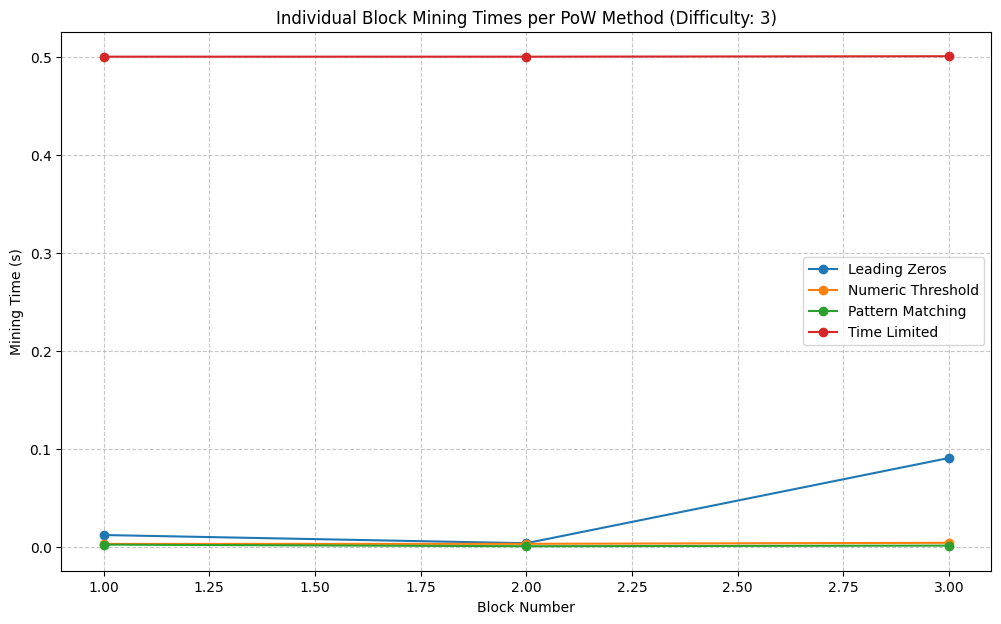

In [13]:

# LAB-LOGBOOK requirement: Show a graph comparing the mining time of the different Proof‑of‑Work methods.

pow_methods = ['leading_zeros', 'numeric_threshold', 'pattern_matching', 'time_limited']
mining_times_per_method = {}

# Define a fixed difficulty and a fixed number of blocks to mine for consistent comparison
fixed_difficulty = 3 # Use a reasonable difficulty for all methods
num_blocks_to_mine = 3
time_limit_for_timed_pow = 0.5 # seconds for the time_limited PoW

print("\n--- Comparing Different Proof-of-Work Methods ---")

for method in pow_methods:
    print(f"\nTesting PoW Method: {method.replace('_', ' ').title()}")
    times_for_method = []
    # Generate a new key for each blockchain instance to ensure isolation
    encryption_key = Fernet.generate_key()
    bc = Blockchain(difficulty=fixed_difficulty, reward=1, encryption_key=encryption_key, pow_method=method)

    for i in range(num_blocks_to_mine):
        bc.add_transaction(f"Sender{i}", f"Recipient{i}", 10)
        if method == 'time_limited':
            t, att = bc.mine_pending("MinerX", time_limit=time_limit_for_timed_pow)
        else:
            t, att = bc.mine_pending("MinerX")
        times_for_method.append(t)
        print(f"Block {bc.chain[-1].index} mined in {t:.4f} seconds (attempts: {att})")
    mining_times_per_method[method] = times_for_method

# --- Visualization ---
plt.figure(figsize=(12, 7))

# Calculate average mining time for each method
avg_times = [sum(times) / len(times) for times in mining_times_per_method.values()]
methods_labels = [m.replace('_', ' ').title() for m in pow_methods]

plt.bar(methods_labels, avg_times, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.xlabel('Proof-of-Work Method')
plt.ylabel('Average Mining Time (s)')
plt.title(f'Average Mining Time for Different PoW Methods (Difficulty: {fixed_difficulty}, {num_blocks_to_mine} Blocks)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Optional: Plot individual block mining times for more detail
plt.figure(figsize=(12, 7))
for method, times in mining_times_per_method.items():
    plt.plot(range(1, num_blocks_to_mine + 1), times, marker='o', label=method.replace('_', ' ').title())

plt.xlabel('Block Number')
plt.ylabel('Mining Time (s)')
plt.title(f'Individual Block Mining Times per PoW Method (Difficulty: {fixed_difficulty})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
